In [1]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.metrics import pairwise_distances, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

step1_dir = Path("./results_step1")
step2_dir = Path("./results_step2")
step3_dir = Path("./results_step3")
step3_dir.mkdir(parents=True, exist_ok=True)

# 1 Required artifact check + configs

In [2]:
step1_required_files = [
    "ratings_filtered.parquet",
    "movies.parquet",
    "users.parquet",
    "train_split_model_universe.parquet",
    "validation_split_model_universe.parquet",
    "test_split_model_universe.parquet",
    "step1_config.json",
]

step2_required_files = [
    "user_embeddings_p_u.npy",
    "item_embeddings_q_i.npy",
    "item_bias.npy",
    "user_embeddings_p_u.parquet",
    "item_embeddings_q_i.parquet",
    "user_index_mapping.parquet",
    "item_index_mapping.parquet",
    "final_step2_config.json",
]

def make_required_file_check(base_dir, filenames, source_name):
    rows = []
    for filename in filenames:
        path = base_dir / filename
        rows.append({
            "source": source_name,
            "filename": filename,
            "exists": path.exists(),
            "size_mb": round(path.stat().st_size / (1024 ** 2), 4) if path.exists() else np.nan,
        })
    return pd.DataFrame(rows)

required_file_check = pd.concat(
    [
        make_required_file_check(step1_dir, step1_required_files, "step1"),
        make_required_file_check(step2_dir, step2_required_files, "step2"),
    ],
    ignore_index=True,
)

display(required_file_check)

missing_required_files = required_file_check[~required_file_check["exists"]]
if len(missing_required_files) > 0:
    display(missing_required_files)
    raise FileNotFoundError("Missing required Step 1 or Step 2 artifacts.")

with open(step1_dir / "step1_config.json", "r") as f:
    step1_config = json.load(f)

with open(step2_dir / "final_step2_config.json", "r") as f:
    step2_config = json.load(f)

random_seed = int(
    step2_config.get(
        "random_seed",
        step1_config.get("random_seed", step1_config.get("seed", 42)),
    )
)

random.seed(random_seed)
np.random.seed(random_seed)

compact_config_summary = pd.DataFrame([
    {
        "config": "step1",
        "dataset": step1_config.get("dataset"),
        "random_seed": step1_config.get("random_seed", step1_config.get("seed")),
        "pair_min_diff": step1_config.get("pair_min_diff"),
        "min_user_ratings": step1_config.get("min_user_ratings"),
        "min_movie_ratings": step1_config.get("min_movie_ratings"),
        "split_strategy": step1_config.get("split_strategy"),
    },
    {
        "config": "step2",
        "embedding_dim": step2_config.get("embedding_dim"),
        "n_users": step2_config.get("n_users"),
        "n_items": step2_config.get("n_items"),
        "selection_metric": step2_config.get("selection_metric"),
        "final_experiment_name": step2_config.get("final_experiment_name"),
    },
])

display(compact_config_summary)
print("random_seed used in Step 3:", random_seed)

,source,filename,exists,size_mb
0,step1,ratings_filtered.parquet,True,8.5200
1,step1,movies.parquet,True,0.0993
2,step1,users.parquet,True,0.0686
3,step1,train_split_model_universe.parquet,True,6.1756
4,step1,validation_split_model_universe.parquet,True,1.0917
5,step1,test_split_model_universe.parquet,True,1.1787
6,step1,step1_config.json,True,0.0006
7,step2,user_embeddings_p_u.npy,True,1.1530
8,step2,item_embeddings_q_i.npy,True,0.7936
9,step2,item_bias.npy,True,0.0125


,config,dataset,random_seed,pair_min_diff,min_user_ratings,min_movie_ratings,split_strategy,embedding_dim,n_users,n_items,selection_metric,final_experiment_name
0,step1,MovieLens 1M,42.0,2.0,40.0,10.0,per_user_temporal_split_with_same_timestamp_gr...,NaN,NaN,NaN,NaN,NaN
1,step2,NaN,NaN,NaN,NaN,NaN,NaN,64.0,4722.0,3250.0,validation_macro_accuracy_best,pair_sampling_gap2_random_cap_dim64_lr3em04_re...


random_seed used in Step 3: 42


# 2 Load data, embeddings, mappings + compact guardrails

In [3]:
ratings_filtered = pd.read_parquet(step1_dir / "ratings_filtered.parquet")
movies = pd.read_parquet(step1_dir / "movies.parquet")
users = pd.read_parquet(step1_dir / "users.parquet")

train_df = pd.read_parquet(step1_dir / "train_split_model_universe.parquet")
val_df = pd.read_parquet(step1_dir / "validation_split_model_universe.parquet")
test_df = pd.read_parquet(step1_dir / "test_split_model_universe.parquet")

user_embeddings_np = np.load(step2_dir / "user_embeddings_p_u.npy")
item_embeddings_np = np.load(step2_dir / "item_embeddings_q_i.npy")
item_bias_np = np.load(step2_dir / "item_bias.npy").reshape(-1)

user_embeddings_df = (
    pd.read_parquet(step2_dir / "user_embeddings_p_u.parquet")
    .sort_values("user_idx")
    .reset_index(drop=True)
)

item_embeddings_df = (
    pd.read_parquet(step2_dir / "item_embeddings_q_i.parquet")
    .sort_values("item_idx")
    .reset_index(drop=True)
)

user_index_mapping = (
    pd.read_parquet(step2_dir / "user_index_mapping.parquet")
    .sort_values("user_idx")
    .reset_index(drop=True)
)

item_index_mapping = (
    pd.read_parquet(step2_dir / "item_index_mapping.parquet")
    .sort_values("item_idx")
    .reset_index(drop=True)
)

user_embedding_cols = sorted([col for col in user_embeddings_df.columns if col.startswith("p_")])
item_embedding_cols = sorted([col for col in item_embeddings_df.columns if col.startswith("q_")])

if len(user_embedding_cols) == 0:
    raise ValueError("No user embedding columns found. Expected columns like p_000.")

if len(item_embedding_cols) == 0:
    raise ValueError("No item embedding columns found. Expected columns like q_000.")

def is_continuous_zero_based(series):
    values = series.to_numpy()
    return (
        len(values) > 0
        and values.min() == 0
        and values.max() == len(values) - 1
        and pd.Series(values).is_unique
    )

assert np.isfinite(user_embeddings_np).all()
assert np.isfinite(item_embeddings_np).all()
assert np.isfinite(item_bias_np).all()

assert is_continuous_zero_based(user_index_mapping["user_idx"])
assert is_continuous_zero_based(item_index_mapping["item_idx"])

assert len(user_index_mapping) == user_embeddings_np.shape[0]
assert len(item_index_mapping) == item_embeddings_np.shape[0]
assert len(item_bias_np) == len(item_index_mapping)

assert user_embeddings_np.shape[1] == len(user_embedding_cols)
assert item_embeddings_np.shape[1] == len(item_embedding_cols)

assert user_index_mapping[["user_idx", "user_id"]].equals(
    user_embeddings_df[["user_idx", "user_id"]]
)

assert item_index_mapping[["item_idx", "movie_id"]].equals(
    item_embeddings_df[["item_idx", "movie_id"]]
)

assert np.allclose(
    user_embeddings_np,
    user_embeddings_df[user_embedding_cols].to_numpy(dtype=np.float32),
    atol=1e-6,
)

assert np.allclose(
    item_embeddings_np,
    item_embeddings_df[item_embedding_cols].to_numpy(dtype=np.float32),
    atol=1e-6,
)

mapped_users = set(user_index_mapping["user_id"])
mapped_items = set(item_index_mapping["movie_id"])

assert set(train_df["user_id"]).issubset(mapped_users)
assert set(val_df["user_id"]).issubset(mapped_users)
assert set(test_df["user_id"]).issubset(mapped_users)

assert set(train_df["movie_id"]).issubset(mapped_items)
assert set(val_df["movie_id"]).issubset(mapped_items)
assert set(test_df["movie_id"]).issubset(mapped_items)

assert mapped_users.issubset(set(users["user_id"]))
assert mapped_items.issubset(set(movies["movie_id"]))

user_metadata_for_step3 = user_index_mapping.merge(
    users,
    on="user_id",
    how="left",
    validate="one_to_one",
)

item_metadata_for_step3 = item_index_mapping.merge(
    movies,
    on="movie_id",
    how="left",
    validate="one_to_one",
)

assert not user_metadata_for_step3.isna().any(axis=1).any()
assert not item_metadata_for_step3.isna().any(axis=1).any()

load_summary = pd.DataFrame([
    {
        "dataset": "ratings_filtered",
        "rows": len(ratings_filtered),
        "users": ratings_filtered["user_id"].nunique(),
        "items": ratings_filtered["movie_id"].nunique(),
    },
    {
        "dataset": "train_model_universe",
        "rows": len(train_df),
        "users": train_df["user_id"].nunique(),
        "items": train_df["movie_id"].nunique(),
    },
    {
        "dataset": "validation_model_universe",
        "rows": len(val_df),
        "users": val_df["user_id"].nunique(),
        "items": val_df["movie_id"].nunique(),
    },
    {
        "dataset": "test_model_universe",
        "rows": len(test_df),
        "users": test_df["user_id"].nunique(),
        "items": test_df["movie_id"].nunique(),
    },
    {
        "dataset": "user_embeddings_p_u",
        "rows": user_embeddings_np.shape[0],
        "users": user_embeddings_np.shape[0],
        "items": np.nan,
        "embedding_dim": user_embeddings_np.shape[1],
    },
    {
        "dataset": "item_embeddings_q_i",
        "rows": item_embeddings_np.shape[0],
        "users": np.nan,
        "items": item_embeddings_np.shape[0],
        "embedding_dim": item_embeddings_np.shape[1],
    },
])

display(load_summary)

,dataset,rows,users,items,embedding_dim
0,ratings_filtered,960916,4726.0,3250.0,NaN
1,train_model_universe,759306,4722.0,3250.0,NaN
2,validation_model_universe,100787,4722.0,3204.0,NaN
3,test_model_universe,100564,4722.0,3226.0,NaN
4,user_embeddings_p_u,4722,4722.0,NaN,64.0
5,item_embeddings_q_i,3250,NaN,3250.0,64.0


# 3 Embedding diagnostics and candidate spaces
### 3.1 Check user and item embedding norms

In [4]:
user_norms = np.linalg.norm(user_embeddings_np, axis=1)
item_norms = np.linalg.norm(item_embeddings_np, axis=1)

norm_summary = pd.DataFrame([
    {
        "entity": "users",
        "count": len(user_norms),
        "mean_norm": user_norms.mean(),
        "std_norm": user_norms.std(),
        "min_norm": user_norms.min(),
        "median_norm": np.median(user_norms),
        "max_norm": user_norms.max(),
    },
    {
        "entity": "items",
        "count": len(item_norms),
        "mean_norm": item_norms.mean(),
        "std_norm": item_norms.std(),
        "min_norm": item_norms.min(),
        "median_norm": np.median(item_norms),
        "max_norm": item_norms.max(),
    },
])

display(norm_summary.round(6))

,entity,count,mean_norm,std_norm,min_norm,median_norm,max_norm
0,users,4722,1.954838,0.419740,0.708360,1.969030,3.252372
1,items,3250,1.939394,0.633035,0.315385,1.865896,4.457988


### 3.2 Per-dimension scale diagnostics

In [5]:
def make_dimension_summary(embedding_matrix, entity_name):
    dim_means = embedding_matrix.mean(axis=0)
    dim_stds = embedding_matrix.std(axis=0)

    return {
        "entity": entity_name,
        "embedding_dim": embedding_matrix.shape[1],
        "mean_abs_dim_mean": float(np.mean(np.abs(dim_means))),
        "max_abs_dim_mean": float(np.max(np.abs(dim_means))),
        "mean_dim_std": float(np.mean(dim_stds)),
        "min_dim_std": float(np.min(dim_stds)),
        "max_dim_std": float(np.max(dim_stds)),
        "near_zero_std_dims": int((dim_stds < 1e-6).sum()),
    }

dimension_summary = pd.DataFrame([
    make_dimension_summary(user_embeddings_np, "users"),
    make_dimension_summary(item_embeddings_np, "items"),
])

display(dimension_summary.round(6))

,entity,embedding_dim,mean_abs_dim_mean,max_abs_dim_mean,mean_dim_std,min_dim_std,max_dim_std,near_zero_std_dims
0,users,64,0.130606,0.160811,0.207571,0.154444,0.284398,0
1,items,64,0.043823,0.073481,0.249562,0.210715,0.315773,0


### 3.3 Build candidate embedding spaces and Compare distance distributions across spaces

In [6]:
user_embeddings_standardized = StandardScaler().fit_transform(user_embeddings_np)
item_embeddings_standardized = StandardScaler().fit_transform(item_embeddings_np)

user_embeddings_l2 = normalize(user_embeddings_np, norm="l2")
item_embeddings_l2 = normalize(item_embeddings_np, norm="l2")

candidate_embedding_spaces = {
    "users": {
        "raw_euclidean": {
            "entity": "users",
            "space": "raw",
            "metric": "euclidean",
            "matrix": user_embeddings_np,
        },
        "standardized_euclidean": {
            "entity": "users",
            "space": "standardized",
            "metric": "euclidean",
            "matrix": user_embeddings_standardized,
        },
        "l2_cosine": {
            "entity": "users",
            "space": "l2_normalized",
            "metric": "cosine",
            "matrix": user_embeddings_l2,
        },
    },
    "items": {
        "raw_euclidean": {
            "entity": "items",
            "space": "raw",
            "metric": "euclidean",
            "matrix": item_embeddings_np,
        },
        "standardized_euclidean": {
            "entity": "items",
            "space": "standardized",
            "metric": "euclidean",
            "matrix": item_embeddings_standardized,
        },
        "l2_cosine": {
            "entity": "items",
            "space": "l2_normalized",
            "metric": "cosine",
            "matrix": item_embeddings_l2,
        },
    },
}

def sample_distance_summary(embedding_matrix, entity, space, metric, sample_size=1200, seed=42):
    rng = np.random.default_rng(seed)
    n_rows = embedding_matrix.shape[0]
    sample_size = min(sample_size, n_rows)

    sample_idx = rng.choice(n_rows, size=sample_size, replace=False)
    sample_matrix = embedding_matrix[sample_idx]

    distance_matrix = pairwise_distances(sample_matrix, metric=metric)
    upper_triangle = distance_matrix[np.triu_indices_from(distance_matrix, k=1)]

    return {
        "entity": entity,
        "space": space,
        "metric": metric,
        "sample_size": sample_size,
        "mean_distance": upper_triangle.mean(),
        "std_distance": upper_triangle.std(),
        "min_distance": upper_triangle.min(),
        "p05_distance": np.percentile(upper_triangle, 5),
        "median_distance": np.median(upper_triangle),
        "p95_distance": np.percentile(upper_triangle, 95),
        "max_distance": upper_triangle.max(),
    }

distance_summary = pd.DataFrame([
    sample_distance_summary(
        config["matrix"],
        config["entity"],
        config["space"],
        config["metric"],
        seed=random_seed,
    )
    for entity_spaces in candidate_embedding_spaces.values()
    for config in entity_spaces.values()
])

display(distance_summary.round(6))

,entity,space,metric,sample_size,mean_distance,std_distance,min_distance,p05_distance,median_distance,p95_distance,max_distance
0,users,raw,euclidean,1200,2.315834,0.497824,0.533449,1.540471,2.291083,3.179285,4.628958
1,users,standardized,euclidean,1200,11.021399,2.363711,2.549834,7.339050,10.903564,15.113030,22.570736
2,users,l2_normalized,cosine,1200,0.698492,0.242210,0.038724,0.319179,0.688652,1.113789,1.777342
3,items,raw,euclidean,1200,2.686850,0.839322,0.427910,1.494064,2.583747,4.230250,7.094010
4,items,standardized,euclidean,1200,10.681432,3.436476,1.626871,5.844924,10.230988,17.031927,28.383076
5,items,l2_normalized,cosine,1200,0.963623,0.353962,0.022348,0.320706,0.984681,1.512644,1.934858


# 4 Candidate min_samples values
### 4.1 Define min_samples candidate rules + Generate and audit candidates

In [7]:
def make_min_samples_candidates(n_rows, embedding_dim):
    raw_specs = [
        ("fixed_baseline", 5, "5"),
        ("log2_n_rows", int(np.ceil(np.log2(n_rows))), "ceil(log2(n_rows))"),
        ("half_percent_n_rows", int(np.ceil(0.005 * n_rows)), "ceil(0.005 * n_rows)"),
        ("half_embedding_dim", int(np.ceil(embedding_dim / 2)), "ceil(embedding_dim / 2)"),
        ("one_percent_n_rows", int(np.ceil(0.01 * n_rows)), "ceil(0.01 * n_rows)"),
        ("embedding_dim", int(embedding_dim), "embedding_dim"),
        ("embedding_dim_plus_1", int(embedding_dim + 1), "embedding_dim + 1"),
    ]

    rows = []
    valid_values = []

    for source, value, formula in raw_specs:
        value = int(value)
        valid = 2 <= value < n_rows

        rows.append({
            "source": source,
            "formula": formula,
            "min_samples": value,
            "n_rows": n_rows,
            "embedding_dim": embedding_dim,
            "valid": valid,
        })

        if valid:
            valid_values.append(value)

    return rows, sorted(set(valid_values))

min_samples_rows = []
min_samples_by_entity = {}

for entity, entity_spaces in candidate_embedding_spaces.items():
    first_matrix = next(iter(entity_spaces.values()))["matrix"]
    n_rows, embedding_dim = first_matrix.shape

    rows, values = make_min_samples_candidates(
        n_rows=n_rows,
        embedding_dim=embedding_dim,
    )

    for row in rows:
        row["entity"] = entity

    min_samples_rows.extend(rows)
    min_samples_by_entity[entity] = values

min_samples_audit = pd.DataFrame(min_samples_rows)
display(min_samples_audit)

min_samples_summary = pd.DataFrame([
    {
        "entity": entity,
        "min_samples_candidates": values,
        "n_candidates": len(values),
    }
    for entity, values in min_samples_by_entity.items()
])

display(min_samples_summary)

,source,formula,min_samples,n_rows,embedding_dim,valid,entity
0,fixed_baseline,5,5,4722,64,True,users
1,log2_n_rows,ceil(log2(n_rows)),13,4722,64,True,users
2,half_percent_n_rows,ceil(0.005 * n_rows),24,4722,64,True,users
3,half_embedding_dim,ceil(embedding_dim / 2),32,4722,64,True,users
4,one_percent_n_rows,ceil(0.01 * n_rows),48,4722,64,True,users
5,embedding_dim,embedding_dim,64,4722,64,True,users
6,embedding_dim_plus_1,embedding_dim + 1,65,4722,64,True,users
7,fixed_baseline,5,5,3250,64,True,items
8,log2_n_rows,ceil(log2(n_rows)),12,3250,64,True,items
9,half_percent_n_rows,ceil(0.005 * n_rows),17,3250,64,True,items


,entity,min_samples_candidates,n_candidates
0,users,"[5, 13, 24, 32, 48, 64, 65]",7
1,items,"[5, 12, 17, 32, 33, 64, 65]",7


# 5 k-distance curves
### 5.1 Define:
- k-distance curve helper
- knee-point eps helper
- curvature-based eps helper

and Compute and summarize k-distance curves

In [8]:
def compute_kdistance_curve(matrix, metric, min_samples):
    n_neighbors = min(int(min_samples), matrix.shape[0])

    nn = NearestNeighbors(
        n_neighbors=n_neighbors,
        metric=metric,
        n_jobs=-1,
    )

    nn.fit(matrix)
    distances, _ = nn.kneighbors(matrix)

    kth_distances = np.sort(distances[:, n_neighbors - 1])
    return kth_distances

def estimate_knee_eps(sorted_distances):
    y = sorted_distances.astype(float)
    n = len(y)

    if n < 3 or np.isclose(y.max(), y.min()):
        return float(np.median(y)), int(n // 2), float(0.5)

    x = np.arange(n, dtype=float)

    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min())

    line_y = y_norm[0] + (y_norm[-1] - y_norm[0]) * x_norm
    distances_from_line = np.abs(y_norm - line_y)

    knee_idx = int(np.argmax(distances_from_line))
    knee_eps = float(y[knee_idx])
    knee_index_share = float(knee_idx / max(n - 1, 1))

    return knee_eps, knee_idx, knee_index_share

def find_curvature_peak_eps(sorted_distances, top_n=7):
    y = sorted_distances.astype(float)
    n = len(y)

    if n < 10 or np.isclose(y.max(), y.min()):
        return []

    y_norm = (y - y.min()) / (y.max() - y.min())

    first_derivative = np.gradient(y_norm)
    second_derivative = np.gradient(first_derivative)
    curvature = np.abs(second_derivative)

    start = max(1, int(0.01 * n))
    end = min(n - 1, int(0.995 * n))

    if end <= start:
        return []

    local_curvature = curvature[start:end]
    top_local_idx = np.argsort(local_curvature)[-top_n:]
    top_idx = sorted(set((top_local_idx + start).astype(int)))

    return [
        {
            "eps": float(y[idx]),
            "index": int(idx),
            "index_share": float(idx / max(n - 1, 1)),
        }
        for idx in top_idx
    ]

kdistance_curves = {}
kdistance_rows = []

for entity, entity_spaces in candidate_embedding_spaces.items():
    for _, config in entity_spaces.items():
        matrix = config["matrix"]
        space = config["space"]
        metric = config["metric"]

        for min_samples in min_samples_by_entity[entity]:
            curve = compute_kdistance_curve(
                matrix=matrix,
                metric=metric,
                min_samples=min_samples,
            )

            knee_eps, knee_idx, knee_index_share = estimate_knee_eps(curve)

            key = (entity, space, metric, int(min_samples))
            kdistance_curves[key] = curve

            kdistance_rows.append({
                "entity": entity,
                "space": space,
                "metric": metric,
                "min_samples": int(min_samples),
                "n_points": matrix.shape[0],
                "knee_eps": knee_eps,
                "knee_index": knee_idx,
                "knee_index_share": knee_index_share,
                "min_kdist": float(np.min(curve)),
                "median_kdist": float(np.median(curve)),
                "mean_kdist": float(np.mean(curve)),
                "max_kdist": float(np.max(curve)),
                "q05_kdist": float(np.quantile(curve, 0.05)),
                "q50_kdist": float(np.quantile(curve, 0.50)),
                "q90_kdist": float(np.quantile(curve, 0.90)),
                "q95_kdist": float(np.quantile(curve, 0.95)),
                "q99_kdist": float(np.quantile(curve, 0.99)),
            })

kdistance_summary = pd.DataFrame(kdistance_rows)
display(kdistance_summary.round(6))

kdistance_summary.to_parquet(
    step3_dir / "kdistance_summary.parquet",
    index=False,
)

,entity,space,metric,min_samples,n_points,knee_eps,knee_index,knee_index_share,min_kdist,median_kdist,mean_kdist,max_kdist,q05_kdist,q50_kdist,q90_kdist,q95_kdist,q99_kdist
0,users,raw,euclidean,5,4722,1.832203,4210,0.891760,0.530620,1.321381,1.379485,2.713488,0.909954,1.321381,1.860548,2.022486,2.313826
1,users,raw,euclidean,13,4722,1.850739,4103,0.869096,0.644488,1.390146,1.446203,2.854310,0.980495,1.390146,1.925097,2.088078,2.397122
2,users,raw,euclidean,24,4722,1.902782,4123,0.873332,0.712143,1.432905,1.490232,2.911017,1.026294,1.432905,1.970671,2.135098,2.446058
3,users,raw,euclidean,32,4722,1.927811,4128,0.874391,0.745084,1.455117,1.512286,2.921164,1.048712,1.455117,1.991923,2.156165,2.472644
4,users,raw,euclidean,48,4722,1.915436,4032,0.854056,0.794132,1.488222,1.545371,2.942826,1.084300,1.488222,2.023470,2.185240,2.494856
5,users,raw,euclidean,64,4722,1.960897,4081,0.864436,0.831884,1.514276,1.570763,2.961359,1.111736,1.514276,2.047660,2.208873,2.521560
6,users,raw,euclidean,65,4722,1.961225,4078,0.863800,0.834138,1.515738,1.572149,2.962542,1.112920,1.515738,2.048526,2.210610,2.523024
7,users,standardized,euclidean,5,4722,8.799217,4193,0.888159,2.392322,6.362675,6.627061,13.303847,4.338056,6.362675,8.962518,9.807644,11.327276
8,users,standardized,euclidean,13,4722,9.146153,4210,0.891760,3.003803,6.669591,6.935861,13.748608,4.653461,6.669591,9.256333,10.089225,11.659032
9,users,standardized,euclidean,24,4722,9.348999,4204,0.890489,3.314701,6.874639,7.142702,14.011614,4.867867,6.874639,9.465232,10.326221,11.847428


### 5.2 Plot representative k-distance curves

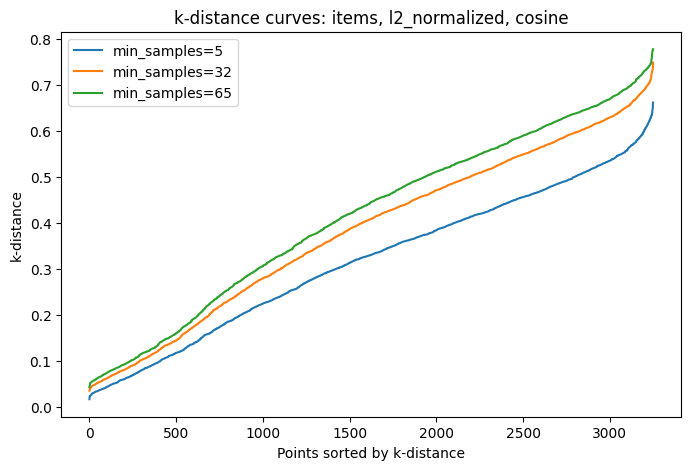

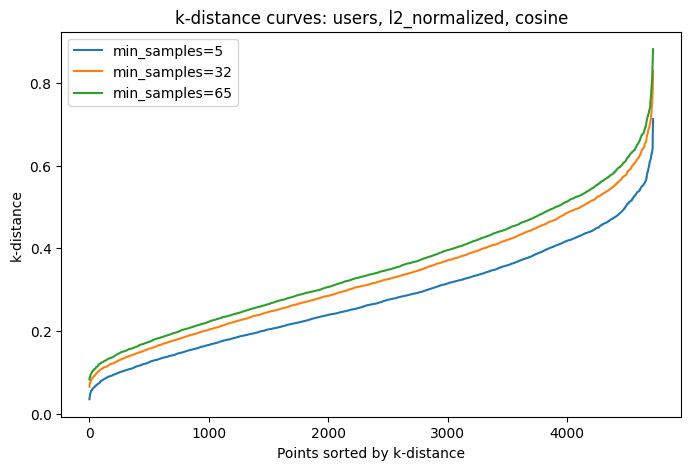

In [9]:
def representative_min_samples(entity):
    values = min_samples_by_entity[entity]
    embedding_dim = (
        user_embeddings_np.shape[1]
        if entity == "users"
        else item_embeddings_np.shape[1]
    )

    targets = [5, int(np.ceil(embedding_dim / 2)), embedding_dim + 1]
    selected = sorted(set(min(values, key=lambda x: abs(x - target)) for target in targets))
    return selected

def plot_kdistance_family(entity, space, metric, min_samples_values):
    plt.figure(figsize=(8, 5))

    for min_samples in min_samples_values:
        key = (entity, space, metric, int(min_samples))
        curve = kdistance_curves[key]

        plt.plot(
            np.arange(len(curve)),
            curve,
            label=f"min_samples={min_samples}",
        )

    plt.xlabel("Points sorted by k-distance")
    plt.ylabel("k-distance")
    plt.title(f"k-distance curves: {entity}, {space}, {metric}")
    plt.legend()
    plt.show()

plot_kdistance_family(
    entity="items",
    space="l2_normalized",
    metric="cosine",
    min_samples_values=representative_min_samples("items"),
)

plot_kdistance_family(
    entity="users",
    space="l2_normalized",
    metric="cosine",
    min_samples_values=representative_min_samples("users"),
)

# 6 Adaptive eps candidate generation
### 6.1 Define eps candidate helper functions and Build eps candidates from knee, quantiles, curvature, and bin edges

In [10]:
def freedman_diaconis_edges(values, max_edges=120):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) < 10:
        return []

    q25, q75 = np.percentile(values, [25, 75])
    iqr = q75 - q25

    if iqr <= 0 or np.isclose(values.max(), values.min()):
        return []

    bin_width = 2 * iqr / (len(values) ** (1 / 3))

    if bin_width <= 0:
        return []

    n_bins = int(np.ceil((values.max() - values.min()) / bin_width))
    n_bins = max(5, min(n_bins, max_edges))

    edges = np.linspace(values.min(), values.max(), n_bins + 1)[1:-1]
    edges = edges[(edges > values.min()) & (edges < values.max())]

    return edges.tolist()

def percentile_rank_for_eps(sorted_distances, eps):
    return float(np.searchsorted(sorted_distances, eps, side="right") / len(sorted_distances))

def build_eps_candidates_from_curve(
    entity,
    space,
    metric,
    min_samples,
    sorted_distances,
    quantiles=None,
):
    if quantiles is None:
        quantiles = [
            0.005, 0.01, 0.02, 0.05,
            0.10, 0.20, 0.30, 0.40, 0.50,
            0.60, 0.70, 0.80, 0.85, 0.90,
            0.95, 0.975, 0.99, 0.995,
        ]

    candidates = {}

    def add_candidate(eps, source):
        if not np.isfinite(eps) or eps <= 0:
            return

        rounded = round(float(eps), 12)

        if rounded not in candidates:
            candidates[rounded] = {
                "eps": float(eps),
                "sources": set(),
            }

        candidates[rounded]["sources"].add(source)

    knee_eps, knee_idx, knee_index_share = estimate_knee_eps(sorted_distances)
    add_candidate(knee_eps, "line_knee")

    for q in quantiles:
        add_candidate(
            np.quantile(sorted_distances, q),
            f"q{int(q * 1000):03d}",
        )

    for peak in find_curvature_peak_eps(sorted_distances, top_n=7):
        add_candidate(peak["eps"], "curvature_peak")

    for edge in freedman_diaconis_edges(sorted_distances, max_edges=120):
        add_candidate(edge, "fd_bin_edge")

    rows = []

    for _, candidate in candidates.items():
        eps = candidate["eps"]

        rows.append({
            "entity": entity,
            "space": space,
            "metric": metric,
            "min_samples": int(min_samples),
            "eps": float(eps),
            "eps_sources": "|".join(sorted(candidate["sources"])),
            "eps_percentile_rank": percentile_rank_for_eps(sorted_distances, eps),
            "knee_eps": float(knee_eps),
            "knee_index": int(knee_idx),
            "knee_index_share": float(knee_index_share),
        })

    return rows

In [11]:
eps_candidate_rows = []

for (entity, space, metric, min_samples), curve in kdistance_curves.items():
    eps_candidate_rows.extend(
        build_eps_candidates_from_curve(
            entity=entity,
            space=space,
            metric=metric,
            min_samples=min_samples,
            sorted_distances=curve,
        )
    )

eps_candidate_table = pd.DataFrame(eps_candidate_rows)

eps_candidate_table["eps_rounded"] = eps_candidate_table["eps"].round(12)

eps_candidate_table = (
    eps_candidate_table
    .groupby(
        ["entity", "space", "metric", "min_samples", "eps_rounded"],
        as_index=False,
    )
    .agg(
        eps=("eps", "first"),
        eps_sources=("eps_sources", lambda x: "|".join(sorted(set("|".join(x).split("|"))))),
        eps_percentile_rank=("eps_percentile_rank", "first"),
        knee_eps=("knee_eps", "first"),
        knee_index=("knee_index", "first"),
        knee_index_share=("knee_index_share", "first"),
    )
    .drop(columns=["eps_rounded"])
    .sort_values(["entity", "space", "metric", "min_samples", "eps"])
    .reset_index(drop=True)
)

eps_grid_summary = (
    eps_candidate_table
    .groupby(["entity", "space", "metric", "min_samples"])
    .agg(
        n_eps_candidates=("eps", "count"),
        min_eps=("eps", "min"),
        median_eps=("eps", "median"),
        max_eps=("eps", "max"),
        min_eps_percentile_rank=("eps_percentile_rank", "min"),
        median_eps_percentile_rank=("eps_percentile_rank", "median"),
        max_eps_percentile_rank=("eps_percentile_rank", "max"),
        knee_eps=("knee_eps", "first"),
        knee_index_share=("knee_index_share", "first"),
    )
    .reset_index()
)

eps_source_summary = (
    eps_candidate_table
    .assign(
        has_fd_bin_edge=eps_candidate_table["eps_sources"].str.contains("fd_bin_edge", regex=False),
        has_line_knee=eps_candidate_table["eps_sources"].str.contains("line_knee", regex=False),
        has_curvature_peak=eps_candidate_table["eps_sources"].str.contains("curvature_peak", regex=False),
    )
    .groupby(["entity", "space", "metric"])
    .agg(
        total_eps_candidates=("eps", "count"),
        fd_candidates=("has_fd_bin_edge", "sum"),
        knee_candidates=("has_line_knee", "sum"),
        curvature_candidates=("has_curvature_peak", "sum"),
        min_percentile_rank=("eps_percentile_rank", "min"),
        max_percentile_rank=("eps_percentile_rank", "max"),
    )
    .reset_index()
)

display(eps_grid_summary.round(6))
display(eps_source_summary.round(6))

eps_candidate_table.to_parquet(
    step3_dir / "eps_candidate_table_adaptive.parquet",
    index=False,
)

eps_grid_summary.to_parquet(
    step3_dir / "eps_grid_summary_adaptive.parquet",
    index=False,
)

eps_source_summary.to_parquet(
    step3_dir / "eps_source_summary_adaptive.parquet",
    index=False,
)

print("Total adaptive eps candidates:", len(eps_candidate_table))

,entity,space,metric,min_samples,n_eps_candidates,min_eps,median_eps,max_eps,min_eps_percentile_rank,median_eps_percentile_rank,max_eps_percentile_rank,knee_eps,knee_index_share
0,items,l2_normalized,cosine,5,44,0.030148,0.423559,0.627998,0.005231,0.702154,0.995077,0.536303,0.924900
1,items,l2_normalized,cosine,12,43,0.037166,0.465966,0.664941,0.005231,0.700000,0.994769,0.578529,0.923053
2,items,l2_normalized,cosine,17,43,0.040208,0.447920,0.681168,0.005231,0.627385,0.994769,0.602214,0.933210
3,items,l2_normalized,cosine,32,43,0.046691,0.471432,0.710103,0.005231,0.615385,0.994769,0.636857,0.935673
4,items,l2_normalized,cosine,33,43,0.047078,0.511632,0.711548,0.005231,0.694769,0.994769,0.637973,0.935673
5,items,l2_normalized,cosine,64,42,0.056060,0.410582,0.742768,0.005231,0.449077,0.994769,0.668883,0.924284
6,items,l2_normalized,cosine,65,42,0.056230,0.361302,0.744427,0.005231,0.380615,0.994769,0.680664,0.939058
7,items,raw,euclidean,5,65,0.565417,2.012444,3.620252,0.002769,0.892615,0.999385,1.949262,0.877193
8,items,raw,euclidean,12,64,0.648534,2.091833,3.700081,0.003692,0.889692,0.999385,2.006585,0.869191
9,items,raw,euclidean,17,64,0.696073,2.131279,3.735855,0.004000,0.891846,0.999385,2.021799,0.864266


,entity,space,metric,total_eps_candidates,fd_candidates,knee_candidates,curvature_candidates,min_percentile_rank,max_percentile_rank
0,items,l2_normalized,cosine,300,118,7,49,0.005231,0.995077
1,items,raw,euclidean,451,269,7,49,0.002769,0.999385
2,items,standardized,euclidean,451,269,7,49,0.002769,0.999385
3,users,l2_normalized,cosine,398,216,7,49,0.004024,0.999788
4,users,raw,euclidean,450,268,7,49,0.000424,0.999788
5,users,standardized,euclidean,453,271,7,49,0.000424,0.999576


Total adaptive eps candidates: 2503


# 7 DBSCAN full tuning over adaptive candidates
### 7.1 Define DBSCAN evaluation helper functions

In [12]:
def get_candidate_matrix(entity, space, metric):
    for _, config in candidate_embedding_spaces[entity].items():
        if config["space"] == space and config["metric"] == metric:
            return config["matrix"]

    raise ValueError(f"No matrix found for entity={entity}, space={space}, metric={metric}")

def summarize_dbscan_labels(labels):
    labels = np.asarray(labels)
    n_points = len(labels)

    noise_mask = labels == -1
    non_noise_labels = labels[~noise_mask]

    n_noise = int(noise_mask.sum())
    noise_share = float(n_noise / n_points)

    clustered_points = int(len(non_noise_labels))
    clustered_share = float(clustered_points / n_points)

    if clustered_points == 0:
        return {
            "n_points": n_points,
            "n_clusters": 0,
            "n_noise": n_noise,
            "noise_share": noise_share,
            "clustered_points": clustered_points,
            "clustered_share": clustered_share,
            "largest_cluster_size": 0,
            "second_largest_cluster_size": 0,
            "smallest_cluster_size": 0,
            "median_cluster_size": 0.0,
            "largest_cluster_share_all": 0.0,
            "largest_cluster_share_clustered": 0.0,
            "second_largest_cluster_share_all": 0.0,
            "second_largest_cluster_share_clustered": 0.0,
            "largest_to_second_ratio": np.nan,
            "effective_n_clusters_hhi": 0.0,
            "normalized_cluster_size_entropy": 0.0,
        }

    cluster_sizes = pd.Series(non_noise_labels).value_counts().sort_values(ascending=False)

    n_clusters = int(cluster_sizes.shape[0])
    largest_cluster_size = int(cluster_sizes.iloc[0])
    second_largest_cluster_size = int(cluster_sizes.iloc[1]) if n_clusters >= 2 else 0
    smallest_cluster_size = int(cluster_sizes.min())
    median_cluster_size = float(cluster_sizes.median())

    cluster_shares = cluster_sizes / clustered_points
    hhi = float((cluster_shares ** 2).sum())
    effective_n_clusters_hhi = float(1 / hhi) if hhi > 0 else 0.0

    if n_clusters > 1:
        entropy = float(-(cluster_shares * np.log(cluster_shares)).sum())
        normalized_entropy = float(entropy / np.log(n_clusters))
    else:
        normalized_entropy = 0.0

    return {
        "n_points": n_points,
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "noise_share": noise_share,
        "clustered_points": clustered_points,
        "clustered_share": clustered_share,
        "largest_cluster_size": largest_cluster_size,
        "second_largest_cluster_size": second_largest_cluster_size,
        "smallest_cluster_size": smallest_cluster_size,
        "median_cluster_size": median_cluster_size,
        "largest_cluster_share_all": float(largest_cluster_size / n_points),
        "largest_cluster_share_clustered": float(largest_cluster_size / clustered_points),
        "second_largest_cluster_share_all": float(second_largest_cluster_size / n_points),
        "second_largest_cluster_share_clustered": float(second_largest_cluster_size / clustered_points),
        "largest_to_second_ratio": (
            float(largest_cluster_size / second_largest_cluster_size)
            if second_largest_cluster_size > 0
            else np.nan
        ),
        "effective_n_clusters_hhi": effective_n_clusters_hhi,
        "normalized_cluster_size_entropy": normalized_entropy,
    }

def stratified_sample_positions(labels, max_points, seed):
    labels = np.asarray(labels)

    if len(labels) <= max_points:
        return np.arange(len(labels))

    rng = np.random.default_rng(seed)
    selected_positions = []

    unique_labels, counts = np.unique(labels, return_counts=True)

    for label, count in zip(unique_labels, counts):
        label_positions = np.where(labels == label)[0]
        quota = int(round(count / len(labels) * max_points))
        quota = max(2, quota)
        quota = min(quota, len(label_positions))

        selected_positions.extend(
            rng.choice(label_positions, size=quota, replace=False).tolist()
        )

    selected_positions = sorted(set(selected_positions))

    if len(selected_positions) > max_points:
        selected_positions = rng.choice(
            selected_positions,
            size=max_points,
            replace=False,
        ).tolist()

    return np.array(sorted(selected_positions), dtype=int)

def safe_silhouette_non_noise(matrix, labels, metric, max_points=2000, seed=42):
    labels = np.asarray(labels)
    non_noise_mask = labels != -1

    if non_noise_mask.sum() < 3:
        return np.nan

    non_noise_labels = labels[non_noise_mask]

    if len(np.unique(non_noise_labels)) < 2:
        return np.nan

    non_noise_matrix = matrix[non_noise_mask]

    sample_positions = stratified_sample_positions(
        labels=non_noise_labels,
        max_points=max_points,
        seed=seed,
    )

    sampled_matrix = non_noise_matrix[sample_positions]
    sampled_labels = non_noise_labels[sample_positions]

    if len(np.unique(sampled_labels)) < 2:
        return np.nan

    try:
        return float(
            silhouette_score(
                sampled_matrix,
                sampled_labels,
                metric=metric,
            )
        )
    except Exception:
        return np.nan

def evaluate_dbscan_candidate(candidate_row, seed=42):
    matrix = get_candidate_matrix(
        entity=candidate_row["entity"],
        space=candidate_row["space"],
        metric=candidate_row["metric"],
    )

    model = DBSCAN(
        eps=float(candidate_row["eps"]),
        min_samples=int(candidate_row["min_samples"]),
        metric=candidate_row["metric"],
        n_jobs=-1,
    )

    labels = model.fit_predict(matrix)

    summary = summarize_dbscan_labels(labels)

    silhouette = np.nan
    if summary["n_clusters"] >= 2 and summary["clustered_points"] >= 20:
        silhouette = safe_silhouette_non_noise(
            matrix=matrix,
            labels=labels,
            metric=candidate_row["metric"],
            max_points=2000,
            seed=seed,
        )

    return {
        **candidate_row.to_dict(),
        **summary,
        "silhouette_non_noise": silhouette,
    }

### 7.2 Evaluate all adaptive DBSCAN candidates, Filter non-trivial structured candidates and Rank candidates with a compromise score

In [13]:
dbscan_result_rows = []

for row_idx, (_, candidate_row) in enumerate(eps_candidate_table.iterrows(), start=1):
    if row_idx == 1 or row_idx % 250 == 0 or row_idx == len(eps_candidate_table):
        print(f"Evaluating DBSCAN candidate {row_idx}/{len(eps_candidate_table)}")

    dbscan_result_rows.append(
        evaluate_dbscan_candidate(
            candidate_row=candidate_row,
            seed=random_seed,
        )
    )

dbscan_tuning_results = pd.DataFrame(dbscan_result_rows)

dbscan_tuning_results["is_structured_candidate"] = (
    (dbscan_tuning_results["n_clusters"] >= 2)
    & (dbscan_tuning_results["clustered_share"] >= 0.05)
    & (dbscan_tuning_results["noise_share"].between(0.02, 0.95))
    & (dbscan_tuning_results["largest_cluster_share_clustered"] <= 0.98)
    & (dbscan_tuning_results["second_largest_cluster_size"] >= 2)
)

silhouette_component = (
    dbscan_tuning_results["silhouette_non_noise"]
    .fillna(-1)
    .clip(lower=-1, upper=1)
    .add(1)
    .div(2)
)

entropy_component = dbscan_tuning_results["normalized_cluster_size_entropy"].fillna(0).clip(0, 1)

dominance_component = (
    1 - dbscan_tuning_results["largest_cluster_share_clustered"].fillna(1)
).clip(0, 1)

noise_component = (
    1 - (dbscan_tuning_results["noise_share"] - 0.35).abs() / 0.35
).clip(0, 1)

cluster_count_component = (
    dbscan_tuning_results["n_clusters"].clip(lower=0, upper=10) / 10
).clip(0, 1)

raw_compromise_score = (
    0.20 * silhouette_component
    + 0.25 * entropy_component
    + 0.25 * dominance_component
    + 0.20 * noise_component
    + 0.10 * cluster_count_component
)

dbscan_tuning_results["compromise_score"] = np.where(
    dbscan_tuning_results["is_structured_candidate"],
    raw_compromise_score,
    -1.0,
)

dbscan_tuning_results.to_parquet(
    step3_dir / "dbscan_tuning_results_adaptive.parquet",
    index=False,
)

structured_summary = (
    dbscan_tuning_results
    .groupby(["entity", "space", "metric"])
    .agg(
        total_candidates=("eps", "count"),
        structured_candidates=("is_structured_candidate", "sum"),
        best_compromise_score=("compromise_score", "max"),
        best_silhouette=("silhouette_non_noise", "max"),
    )
    .reset_index()
)

display(structured_summary.round(6))

Evaluating DBSCAN candidate 1/2503
Evaluating DBSCAN candidate 250/2503
Evaluating DBSCAN candidate 500/2503
Evaluating DBSCAN candidate 750/2503
Evaluating DBSCAN candidate 1000/2503
Evaluating DBSCAN candidate 1250/2503
Evaluating DBSCAN candidate 1500/2503
Evaluating DBSCAN candidate 1750/2503
Evaluating DBSCAN candidate 2000/2503
Evaluating DBSCAN candidate 2250/2503
Evaluating DBSCAN candidate 2500/2503
Evaluating DBSCAN candidate 2503/2503


,entity,space,metric,total_candidates,structured_candidates,best_compromise_score,best_silhouette
0,items,l2_normalized,cosine,300,62,0.6655,0.925454
1,items,raw,euclidean,451,0,-1.0000,0.369739
2,items,standardized,euclidean,451,0,-1.0000,0.428112
3,users,l2_normalized,cosine,398,0,-1.0000,0.402041
4,users,raw,euclidean,450,0,-1.0000,NaN
5,users,standardized,euclidean,453,0,-1.0000,0.284656


### 7.3 Display top structured DBSCAN candidates

In [14]:
top_structured_candidates = (
    dbscan_tuning_results[dbscan_tuning_results["is_structured_candidate"]]
    .sort_values(
        ["compromise_score", "effective_n_clusters_hhi", "silhouette_non_noise"],
        ascending=[False, False, False],
    )
    .head(20)
)

display(
    top_structured_candidates[
        [
            "entity",
            "space",
            "metric",
            "min_samples",
            "eps",
            "eps_sources",
            "eps_percentile_rank",
            "n_clusters",
            "noise_share",
            "clustered_share",
            "largest_cluster_share_clustered",
            "second_largest_cluster_share_clustered",
            "effective_n_clusters_hhi",
            "normalized_cluster_size_entropy",
            "silhouette_non_noise",
            "compromise_score",
        ]
    ].round(6)
)

print("Saved:", step3_dir / "dbscan_tuning_results_adaptive.parquet")

,entity,space,metric,min_samples,eps,eps_sources,eps_percentile_rank,n_clusters,noise_share,clustered_share,largest_cluster_share_clustered,second_largest_cluster_share_clustered,effective_n_clusters_hhi,normalized_cluster_size_entropy,silhouette_non_noise,compromise_score
279,items,l2_normalized,cosine,65,0.376588,q400,0.400000,2,0.383385,0.616615,0.687126,0.312874,1.754287,0.896463,0.622422,0.665500
235,items,l2_normalized,cosine,64,0.375748,q400,0.400000,2,0.384308,0.615692,0.686657,0.313343,1.755367,0.896995,0.623164,0.665297
187,items,l2_normalized,cosine,33,0.345791,q400,0.400000,2,0.424615,0.575385,0.698396,0.301604,1.727946,0.883243,0.641765,0.637751
145,items,l2_normalized,cosine,32,0.344377,q400,0.400000,2,0.427692,0.572308,0.698925,0.301075,1.726692,0.882601,0.643261,0.635850
278,items,l2_normalized,cosine,65,0.346017,fd_bin_edge,0.361231,2,0.442769,0.557231,0.710105,0.289895,1.699847,0.868586,0.661993,0.622808
234,items,l2_normalized,cosine,64,0.345856,fd_bin_edge,0.361538,2,0.442769,0.557231,0.710105,0.289895,1.699847,0.868586,0.661860,0.622795
186,items,l2_normalized,cosine,33,0.313641,fd_bin_edge,0.354769,2,0.494462,0.505538,0.729154,0.270846,1.652829,0.842676,0.695911,0.585422
144,items,l2_normalized,cosine,32,0.313066,fd_bin_edge,0.355692,2,0.494769,0.505231,0.729598,0.270402,1.651717,0.842041,0.696028,0.584988
101,items,l2_normalized,cosine,17,0.295626,fd_bin_edge,0.361846,2,0.520000,0.480000,0.741667,0.258333,1.621256,0.824221,0.709846,0.564480
57,items,l2_normalized,cosine,12,0.282931,fd_bin_edge,0.362154,2,0.537231,0.462769,0.748670,0.251330,1.603402,0.813379,0.715254,0.550714


Saved: results_step3\dbscan_tuning_results_adaptive.parquet


# 8 Select clean candidates and refit labels

### 8.1 
- Build structured candidate selection pool
- Select main and diagnostic item candidates
- Check for stable user-side candidates
- Combine selected candidates and assign clean candidate IDs

In [15]:
candidate_selection_pool = dbscan_tuning_results[
    dbscan_tuning_results["is_structured_candidate"]
].copy()

main_candidate_pool = candidate_selection_pool[
    (candidate_selection_pool["entity"] == "items")
    & (candidate_selection_pool["space"] == "l2_normalized")
    & (candidate_selection_pool["metric"] == "cosine")
    & (candidate_selection_pool["n_clusters"].between(2, 20))
    & (candidate_selection_pool["noise_share"].between(0.05, 0.85))
].copy()

if len(main_candidate_pool) == 0:
    raise ValueError("No valid main item L2-cosine DBSCAN candidate found.")

def add_selection_role(df, role):
    out = df.copy()
    out["selection_role"] = role
    return out

clean_selection_parts = []

clean_selection_parts.append(
    add_selection_role(
        main_candidate_pool
        .sort_values(
            ["compromise_score", "effective_n_clusters_hhi", "silhouette_non_noise"],
            ascending=[False, False, False],
        )
        .head(1),
        "main_item_l2_cosine_compromise",
    )
)

clean_selection_parts.append(
    add_selection_role(
        main_candidate_pool
        .sort_values("silhouette_non_noise", ascending=False)
        .head(1),
        "diagnostic_best_item_l2_cosine_silhouette",
    )
)

clean_selection_parts.append(
    add_selection_role(
        main_candidate_pool
        .sort_values(
            ["effective_n_clusters_hhi", "normalized_cluster_size_entropy", "silhouette_non_noise"],
            ascending=[False, False, False],
        )
        .head(1),
        "diagnostic_best_item_l2_cosine_balance",
    )
)

user_candidate_pool = candidate_selection_pool[
    (candidate_selection_pool["entity"] == "users")
    & (candidate_selection_pool["space"] == "l2_normalized")
    & (candidate_selection_pool["metric"] == "cosine")
].copy()

if len(user_candidate_pool) == 0:
    user_candidate_pool = candidate_selection_pool[
        candidate_selection_pool["entity"] == "users"
    ].copy()

if len(user_candidate_pool) > 0:
    clean_selection_parts.append(
        add_selection_role(
            user_candidate_pool
            .sort_values("compromise_score", ascending=False)
            .head(1),
            "diagnostic_best_user_candidate",
        )
    )

clean_dbscan_selection_raw = pd.concat(clean_selection_parts, ignore_index=True)

candidate_key_cols = [
    "entity",
    "space",
    "metric",
    "min_samples",
    "eps",
]

agg_cols = {
    "selection_role": lambda x: "|".join(sorted(set(x))),
    "eps_sources": "first",
    "eps_percentile_rank": "first",
    "knee_eps": "first",
    "knee_index_share": "first",
    "n_points": "first",
    "n_clusters": "first",
    "n_noise": "first",
    "noise_share": "first",
    "clustered_share": "first",
    "largest_cluster_size": "first",
    "second_largest_cluster_size": "first",
    "largest_cluster_share_all": "first",
    "largest_cluster_share_clustered": "first",
    "second_largest_cluster_share_all": "first",
    "second_largest_cluster_share_clustered": "first",
    "largest_to_second_ratio": "first",
    "silhouette_non_noise": "first",
    "effective_n_clusters_hhi": "first",
    "normalized_cluster_size_entropy": "first",
    "compromise_score": "first",
}

clean_dbscan_selection = (
    clean_dbscan_selection_raw
    .groupby(candidate_key_cols, as_index=False)
    .agg(agg_cols)
    .rename(columns={"selection_role": "selection_roles"})
    .sort_values(
        ["entity", "compromise_score", "effective_n_clusters_hhi"],
        ascending=[True, False, False],
    )
    .reset_index(drop=True)
)

clean_dbscan_selection["clean_candidate_id"] = [
    f"clean_dbscan_candidate_{i:02d}"
    for i in range(len(clean_dbscan_selection))
]

display(
    clean_dbscan_selection[
        [
            "clean_candidate_id",
            "entity",
            "space",
            "metric",
            "min_samples",
            "eps",
            "selection_roles",
            "n_clusters",
            "noise_share",
            "largest_cluster_share_clustered",
            "second_largest_cluster_share_clustered",
            "silhouette_non_noise",
            "compromise_score",
        ]
    ].round(6)
)

clean_dbscan_selection.to_parquet(
    step3_dir / "clean_dbscan_selection.parquet",
    index=False,
)

,clean_candidate_id,entity,space,metric,min_samples,eps,selection_roles,n_clusters,noise_share,largest_cluster_share_clustered,second_largest_cluster_share_clustered,silhouette_non_noise,compromise_score
0,clean_dbscan_candidate_00,items,l2_normalized,cosine,65,0.376588,main_item_l2_cosine_compromise,2,0.383385,0.687126,0.312874,0.622422,0.665500
1,clean_dbscan_candidate_01,items,l2_normalized,cosine,64,0.375748,diagnostic_best_item_l2_cosine_balance,2,0.384308,0.686657,0.313343,0.623164,0.665297
2,clean_dbscan_candidate_02,items,l2_normalized,cosine,5,0.119324,diagnostic_best_item_l2_cosine_silhouette,2,0.817846,0.949324,0.050676,0.895482,0.294532


### 8.2
- Define entity mapping helper for selected DBSCAN labels
- Refit DBSCAN labels for selected candidates
- Build clean label tables and cluster-size summary

In [16]:
def get_entity_mapping(entity):
    if entity == "items":
        mapping = item_index_mapping.rename(
            columns={
                "item_idx": "object_idx",
                "movie_id": "object_id",
            }
        ).copy()
    elif entity == "users":
        mapping = user_index_mapping.rename(
            columns={
                "user_idx": "object_idx",
                "user_id": "object_id",
            }
        ).copy()
    else:
        raise ValueError(f"Unknown entity: {entity}")

    return mapping[["object_idx", "object_id"]].sort_values("object_idx").reset_index(drop=True)

def refit_dbscan_labels(candidate_row):
    matrix = get_candidate_matrix(
        entity=candidate_row["entity"],
        space=candidate_row["space"],
        metric=candidate_row["metric"],
    )

    model = DBSCAN(
        eps=float(candidate_row["eps"]),
        min_samples=int(candidate_row["min_samples"]),
        metric=candidate_row["metric"],
        n_jobs=-1,
    )

    labels = model.fit_predict(matrix)

    label_table = get_entity_mapping(candidate_row["entity"])
    label_table["cluster_label"] = labels.astype(int)
    label_table["is_noise"] = label_table["cluster_label"].eq(-1)

    label_table["clean_candidate_id"] = candidate_row["clean_candidate_id"]
    label_table["entity"] = candidate_row["entity"]
    label_table["space"] = candidate_row["space"]
    label_table["metric"] = candidate_row["metric"]
    label_table["eps"] = float(candidate_row["eps"])
    label_table["min_samples"] = int(candidate_row["min_samples"])

    return label_table

clean_label_tables = []

for _, candidate in clean_dbscan_selection.iterrows():
    clean_label_tables.append(refit_dbscan_labels(candidate))

clean_dbscan_labels = pd.concat(clean_label_tables, ignore_index=True)

clean_dbscan_cluster_sizes = (
    clean_dbscan_labels
    .groupby(["clean_candidate_id", "entity", "cluster_label", "is_noise"])
    .size()
    .reset_index(name="cluster_size")
    .sort_values(["clean_candidate_id", "cluster_label"])
)

display(clean_dbscan_cluster_sizes)

clean_dbscan_labels.to_parquet(
    step3_dir / "clean_dbscan_labels.parquet",
    index=False,
)

clean_dbscan_cluster_sizes.to_parquet(
    step3_dir / "clean_dbscan_cluster_sizes.parquet",
    index=False,
)

,clean_candidate_id,entity,cluster_label,is_noise,cluster_size
0,clean_dbscan_candidate_00,items,-1,True,1246
1,clean_dbscan_candidate_00,items,0,False,1377
2,clean_dbscan_candidate_00,items,1,False,627
3,clean_dbscan_candidate_01,items,-1,True,1249
4,clean_dbscan_candidate_01,items,0,False,1374
5,clean_dbscan_candidate_01,items,1,False,627
6,clean_dbscan_candidate_02,items,-1,True,2658
7,clean_dbscan_candidate_02,items,0,False,562
8,clean_dbscan_candidate_02,items,1,False,30


# 9 Interpret main item DBSCAN candidate

### 9.1 Display selected main item DBSCAN candidate

In [17]:
main_item_candidate_row = clean_dbscan_selection[
    clean_dbscan_selection["selection_roles"].str.contains(
        "main_item_l2_cosine_compromise",
        regex=False,
    )
].iloc[0]

main_item_candidate_id = main_item_candidate_row["clean_candidate_id"]

print("Main item DBSCAN candidate:")
display(main_item_candidate_row.to_frame().T)

Main item DBSCAN candidate:


,entity,space,metric,min_samples,eps,selection_roles,eps_sources,eps_percentile_rank,knee_eps,knee_index_share,...,largest_cluster_share_all,largest_cluster_share_clustered,second_largest_cluster_share_all,second_largest_cluster_share_clustered,largest_to_second_ratio,silhouette_non_noise,effective_n_clusters_hhi,normalized_cluster_size_entropy,compromise_score,clean_candidate_id
0,items,l2_normalized,cosine,65,0.376588,main_item_l2_cosine_compromise,q400,0.4,0.680664,0.939058,...,0.423692,0.687126,0.192923,0.312874,2.196172,0.622422,1.754287,0.896463,0.6655,clean_dbscan_candidate_00


### 9.2 Display cluster-size summary for the selected item candidate

In [18]:
main_item_labels = clean_dbscan_labels[
    clean_dbscan_labels["clean_candidate_id"] == main_item_candidate_id
].copy()

display(
    main_item_labels
    .groupby(["cluster_label", "is_noise"])
    .size()
    .reset_index(name="n_items")
    .sort_values("cluster_label")
)

,cluster_label,is_noise,n_items
0,-1,True,1246
1,0,False,1377
2,1,False,627


### 9.3 
- Compute item activity statistics
- Add movie metadata, rating activity, and item bias
- Extract movie release year
- Compute distance to item cluster centroids
- Build item cluster profiles

In [19]:
item_activity = (
    ratings_filtered
    .groupby("movie_id")
    .agg(
        total_ratings=("rating", "size"),
        mean_rating=("rating", "mean"),
        median_rating=("rating", "median"),
        rating_std=("rating", "std"),
        first_timestamp=("timestamp", "min"),
        last_timestamp=("timestamp", "max"),
    )
    .reset_index()
)

train_item_activity = (
    train_df
    .groupby("movie_id")
    .agg(
        train_ratings=("rating", "size"),
        train_mean_rating=("rating", "mean"),
    )
    .reset_index()
)

item_bias_table = item_index_mapping.copy()
item_bias_table["item_bias"] = item_bias_np

main_item_profile = (
    main_item_labels
    .merge(
        movies,
        left_on="object_id",
        right_on="movie_id",
        how="left",
        validate="many_to_one",
    )
    .merge(
        item_activity,
        on="movie_id",
        how="left",
        validate="many_to_one",
    )
    .merge(
        train_item_activity,
        on="movie_id",
        how="left",
        validate="many_to_one",
    )
    .merge(
        item_bias_table,
        on="movie_id",
        how="left",
        validate="many_to_one",
    )
)

main_item_profile["train_ratings"] = main_item_profile["train_ratings"].fillna(0).astype(int)

main_item_profile["year"] = (
    main_item_profile["title"]
    .str.extract(r"\((\d{4})\)")
    .astype(float)
)

def add_distance_to_cluster_centroid(profile, matrix, metric):
    out = profile.copy()
    out["distance_to_cluster_centroid"] = np.nan

    for cluster_label, group in out[~out["is_noise"]].groupby("cluster_label"):
        object_indices = group["object_idx"].to_numpy(dtype=int)
        cluster_matrix = matrix[object_indices]
        centroid = cluster_matrix.mean(axis=0, keepdims=True)

        distances = pairwise_distances(
            cluster_matrix,
            centroid,
            metric=metric,
        ).reshape(-1)

        out.loc[group.index, "distance_to_cluster_centroid"] = distances

    return out

main_item_matrix = get_candidate_matrix(
    entity=main_item_candidate_row["entity"],
    space=main_item_candidate_row["space"],
    metric=main_item_candidate_row["metric"],
)

main_item_profile = add_distance_to_cluster_centroid(
    profile=main_item_profile,
    matrix=main_item_matrix,
    metric=main_item_candidate_row["metric"],
)

def top_genres_string(df, top_n=5):
    genres = (
        df["genres"]
        .dropna()
        .str.split("|")
        .explode()
    )

    if len(genres) == 0:
        return ""

    genre_share = genres.value_counts(normalize=True).head(top_n)

    return ", ".join(
        f"{genre} ({share:.2f})"
        for genre, share in genre_share.items()
    )

genre_profile_rows = []

for cluster_label, group in main_item_profile.groupby("cluster_label"):
    genre_profile_rows.append({
        "cluster_label": cluster_label,
        "top_genres": top_genres_string(group, top_n=5),
    })

genre_profile = pd.DataFrame(genre_profile_rows)

item_cluster_profile = (
    main_item_profile
    .groupby(["cluster_label", "is_noise"])
    .agg(
        n_items=("movie_id", "size"),
        avg_total_ratings=("total_ratings", "mean"),
        median_total_ratings=("total_ratings", "median"),
        avg_train_ratings=("train_ratings", "mean"),
        avg_mean_rating=("mean_rating", "mean"),
        median_mean_rating=("mean_rating", "median"),
        avg_item_bias=("item_bias", "mean"),
        median_year=("year", "median"),
    )
    .reset_index()
)

item_cluster_profile["share_items"] = (
    item_cluster_profile["n_items"] / item_cluster_profile["n_items"].sum()
)

item_cluster_profile = item_cluster_profile.merge(
    genre_profile,
    on="cluster_label",
    how="left",
)

display(item_cluster_profile.round(4))

,cluster_label,is_noise,n_items,avg_total_ratings,median_total_ratings,avg_train_ratings,avg_mean_rating,median_mean_rating,avg_item_bias,median_year,share_items,top_genres
0,-1,True,1246,408.8379,261.5,329.0835,3.5563,3.5592,0.0147,1993.0,0.3834,"Drama (0.24), Comedy (0.18), Romance (0.09), T..."
1,0,False,1377,175.0799,109.0,128.4067,2.7240,2.7750,-0.1359,1995.0,0.4237,"Comedy (0.21), Drama (0.15), Action (0.11), Ho..."
2,1,False,627,335.5965,170.0,275.0431,3.9736,3.9885,0.1214,1980.0,0.1929,"Drama (0.35), Comedy (0.14), Romance (0.08), T..."


### 9.4 Display representative movies closest to each item cluster centroid

In [20]:
cluster_representatives = (
    main_item_profile[~main_item_profile["is_noise"]]
    .sort_values(
        ["cluster_label", "distance_to_cluster_centroid", "total_ratings"],
        ascending=[True, True, False],
    )
    .groupby("cluster_label")
    .head(8)
    [
        [
            "cluster_label",
            "title",
            "genres",
            "total_ratings",
            "mean_rating",
            "item_bias",
            "distance_to_cluster_centroid",
        ]
    ]
)

print("Representative movies near cluster centroids:")
display(cluster_representatives.round(4))

Representative movies near cluster centroids:


,cluster_label,title,genres,total_ratings,mean_rating,item_bias,distance_to_cluster_centroid
431,0,Jimmy Hollywood (1994),Comedy,23,2.4348,-0.1046,0.0159
384,0,Calendar Girl (1993),Drama,24,2.4167,-0.2086,0.0159
1201,0,B*A*P*S (1997),Comedy,26,1.8077,-0.2992,0.0186
244,0,Man of the House (1995),Comedy,23,2.3043,-0.1523,0.0193
2924,0,Carnosaur 3: Primal Species (1996),Horror|Sci-Fi,17,1.0588,-0.2789,0.0197
2678,0,Stop! Or My Mom Will Shoot (1992),Action|Comedy,175,1.7829,-0.3000,0.0197
2994,0,Rent-A-Cop (1988),Action|Comedy,34,1.8824,-0.2998,0.0201
2563,0,Miss Julie (1999),Drama,10,2.6000,-0.1023,0.0203
580,1,Aparajito (1956),Drama,21,4.2857,0.2886,0.0430
2267,1,"Marcello Mastroianni: I Remember Yes, I Rememb...",Documentary,12,4.0000,0.1518,0.0537


### 9.5 Analyze popular movies in the DBSCAN noise group

In [21]:
noise_representatives = (
    main_item_profile[main_item_profile["is_noise"]]
    .sort_values(["total_ratings", "mean_rating"], ascending=False)
    .head(12)
    [
        [
            "cluster_label",
            "title",
            "genres",
            "total_ratings",
            "mean_rating",
            "item_bias",
        ]
    ]
)

print("Popular representative noise movies:")
display(noise_representatives.round(4))

Popular representative noise movies:


,cluster_label,title,genres,total_ratings,mean_rating,item_bias
2337,-1,American Beauty (1999),Comedy|Drama,2936,4.3137,0.1268
962,-1,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Romance|Sci-Fi|War,2564,4.0433,0.0136
530,-1,Terminator 2: Judgment Day (1991),Action|Sci-Fi|Thriller,2436,4.0587,0.1297
2089,-1,"Matrix, The (1999)",Action|Sci-Fi|Thriller,2435,4.3076,0.1812
433,-1,Jurassic Park (1993),Action|Adventure|Sci-Fi,2412,3.7736,-0.1009
1258,-1,Men in Black (1997),Action|Adventure|Comedy|Sci-Fi,2394,3.7414,0.0971
1020,-1,Back to the Future (1985),Comedy|Sci-Fi,2382,4.0029,0.1165
1934,-1,Shakespeare in Love (1998),Comedy|Romance,2197,4.1238,0.0974
97,-1,Braveheart (1995),Action|Drama|War,2182,4.2406,0.0867
1015,-1,Groundhog Day (1993),Comedy|Romance,2163,3.9649,0.1634


### 9.6 Compare item-level statistics for noise and clustered groups

In [22]:
item_noise_vs_clustered = (
    main_item_profile
    .assign(group=np.where(main_item_profile["is_noise"], "noise", "clustered"))
    .groupby("group")
    .agg(
        n_items=("movie_id", "size"),
        avg_total_ratings=("total_ratings", "mean"),
        median_total_ratings=("total_ratings", "median"),
        avg_train_ratings=("train_ratings", "mean"),
        avg_mean_rating=("mean_rating", "mean"),
        avg_item_bias=("item_bias", "mean"),
        median_year=("year", "median"),
    )
    .reset_index()
)

display(item_noise_vs_clustered.round(4))

,group,n_items,avg_total_ratings,median_total_ratings,avg_train_ratings,avg_mean_rating,avg_item_bias,median_year
0,clustered,2004,225.3014,121.0,174.2854,3.1150,-0.0554,1994.0
1,noise,1246,408.8379,261.5,329.0835,3.5563,0.0147,1993.0


In [23]:
item_cluster_profile.to_parquet(
    step3_dir / "main_item_cluster_profile.parquet",
    index=False,
)

cluster_representatives.to_parquet(
    step3_dir / "main_item_cluster_representatives.parquet",
    index=False,
)

noise_representatives.to_parquet(
    step3_dir / "main_item_noise_representatives.parquet",
    index=False,
)

item_noise_vs_clustered.to_parquet(
    step3_dir / "main_item_noise_vs_clustered.parquet",
    index=False,
)

print("Saved main item interpretation artifacts.")

Saved main item interpretation artifacts.


# 10 Diagnostic user DBSCAN interpretation

In [24]:
user_diag_rows = clean_dbscan_selection[
    clean_dbscan_selection["selection_roles"].str.contains(
        "diagnostic_best_user_candidate",
        regex=False,
    )
].copy()

if len(user_diag_rows) > 0:
    user_diag_candidate_row = user_diag_rows.iloc[0]
    user_diag_candidate_id = user_diag_candidate_row["clean_candidate_id"]

    print("Diagnostic user DBSCAN candidate:")
    display(user_diag_candidate_row.to_frame().T)

    user_diag_labels = clean_dbscan_labels[
        clean_dbscan_labels["clean_candidate_id"] == user_diag_candidate_id
    ].copy()

    display(
        user_diag_labels
        .groupby(["cluster_label", "is_noise"])
        .size()
        .reset_index(name="n_users")
        .sort_values("cluster_label")
    )

    user_activity = (
        ratings_filtered
        .groupby("user_id")
        .agg(
            total_ratings=("rating", "size"),
            mean_rating=("rating", "mean"),
            rating_std=("rating", "std"),
        )
        .reset_index()
    )

    train_user_activity = (
        train_df
        .groupby("user_id")
        .agg(
            train_ratings=("rating", "size"),
            train_mean_rating=("rating", "mean"),
        )
        .reset_index()
    )

    user_diag_profile = (
        user_diag_labels
        .merge(
            users,
            left_on="object_id",
            right_on="user_id",
            how="left",
            validate="many_to_one",
        )
        .merge(
            user_activity,
            on="user_id",
            how="left",
            validate="many_to_one",
        )
        .merge(
            train_user_activity,
            on="user_id",
            how="left",
            validate="many_to_one",
        )
    )

    user_diag_profile["train_ratings"] = user_diag_profile["train_ratings"].fillna(0).astype(int)

    user_cluster_profile = (
        user_diag_profile
        .groupby(["cluster_label", "is_noise"])
        .agg(
            n_users=("user_id", "size"),
            avg_total_ratings=("total_ratings", "mean"),
            median_total_ratings=("total_ratings", "median"),
            avg_train_ratings=("train_ratings", "mean"),
            median_train_ratings=("train_ratings", "median"),
            avg_mean_rating=("mean_rating", "mean"),
            avg_rating_std=("rating_std", "mean"),
            female_share=("gender", lambda x: (x == "F").mean()),
            median_age_code=("age", "median"),
        )
        .reset_index()
    )

    user_cluster_profile["share_users"] = (
        user_cluster_profile["n_users"] / user_cluster_profile["n_users"].sum()
    )

    user_noise_vs_clustered = (
        user_diag_profile
        .assign(group=np.where(user_diag_profile["is_noise"], "noise", "clustered"))
        .groupby("group")
        .agg(
            n_users=("user_id", "size"),
            avg_total_ratings=("total_ratings", "mean"),
            median_total_ratings=("total_ratings", "median"),
            avg_train_ratings=("train_ratings", "mean"),
            median_train_ratings=("train_ratings", "median"),
            avg_mean_rating=("mean_rating", "mean"),
            avg_rating_std=("rating_std", "mean"),
            female_share=("gender", lambda x: (x == "F").mean()),
            median_age_code=("age", "median"),
        )
        .reset_index()
    )

    display(user_cluster_profile.round(4))
    display(user_noise_vs_clustered.round(4))

    user_cluster_profile.to_parquet(
        step3_dir / "diagnostic_user_cluster_profile.parquet",
        index=False,
    )

    user_noise_vs_clustered.to_parquet(
        step3_dir / "diagnostic_user_noise_vs_clustered.parquet",
        index=False,
    )

    user_diag_labels.to_parquet(
        step3_dir / "diagnostic_user_dbscan_labels.parquet",
        index=False,
    )

    print("Saved diagnostic user DBSCAN artifacts.")

else:
    user_diag_candidate_row = None
    user_cluster_profile = None
    user_noise_vs_clustered = None
    print("No diagnostic user DBSCAN candidate found.")

No diagnostic user DBSCAN candidate found.


# 11 Final Step 3 decision + final artifacts

### 11.1 
- Build final item DBSCAN label table
- Store selected DBSCAN parameters
- Summarize diagnostic user DBSCAN evidence
- Create final Step 3 decision table

In [25]:
final_item_dbscan_labels = main_item_profile.copy()

final_item_dbscan_labels["item_idx"] = final_item_dbscan_labels["object_idx"].astype(int)
final_item_dbscan_labels["movie_id"] = final_item_dbscan_labels["object_id"].astype(int)

final_item_dbscan_labels["dbscan_item_group"] = np.where(
    final_item_dbscan_labels["cluster_label"].eq(-1),
    "noise",
    "cluster_" + final_item_dbscan_labels["cluster_label"].astype(str),
)

final_item_dbscan_labels = final_item_dbscan_labels[
    [
        "item_idx",
        "movie_id",
        "title",
        "genres",
        "cluster_label",
        "is_noise",
        "dbscan_item_group",
        "total_ratings",
        "mean_rating",
        "median_rating",
        "train_ratings",
        "train_mean_rating",
        "item_bias",
        "year",
        "distance_to_cluster_centroid",
    ]
].copy()

selected_eps = float(main_item_candidate_row["eps"])
selected_min_samples = int(main_item_candidate_row["min_samples"])

if user_diag_candidate_row is not None:
    user_noise_count = int(
        user_cluster_profile.loc[user_cluster_profile["is_noise"], "n_users"].iloc[0]
    )
    user_total_count = int(user_cluster_profile["n_users"].sum())
    user_noise_evidence = (
        f"The diagnostic user DBSCAN candidate placed {user_noise_count} of "
        f"{user_total_count} users in noise."
    )
else:
    user_noise_evidence = "No stable user DBSCAN candidate was selected."

final_step3_decision = pd.DataFrame([
    {
        "decision_area": "clustering_target",
        "selected_value": "items_q_i",
        "evidence": (
            "Item embeddings produced interpretable non-trivial DBSCAN structure. "
            "User clustering is kept only as a diagnostic check."
        ),
    },
    {
        "decision_area": "joint_space",
        "selected_value": "not_used_as_main",
        "evidence": (
            "Users and items are different entity types in the BPR model. "
            "A concatenated joint space would be harder to interpret for group recommendation."
        ),
    },
    {
        "decision_area": "preprocessing",
        "selected_value": "L2-normalized item embeddings",
        "evidence": (
            "L2-normalized cosine space was selected for the main item-side DBSCAN candidate. "
            "Raw and standardized Euclidean spaces were screened but not used as the final decision."
        ),
    },
    {
        "decision_area": "distance_metric",
        "selected_value": "cosine",
        "evidence": (
            "Cosine distance on L2-normalized item embeddings focuses on taste direction "
            "rather than raw embedding magnitude."
        ),
    },
    {
        "decision_area": "eps",
        "selected_value": f"{selected_eps:.6f}",
        "evidence": (
            "eps was selected from adaptive k-distance candidates using line-knee, curvature, "
            "quantile, and Freedman-Diaconis bin-edge sources. "
            f"Selected eps sources: {main_item_candidate_row['eps_sources']}; "
            f"eps percentile rank: {float(main_item_candidate_row['eps_percentile_rank']):.4f}."
        ),
    },
    {
        "decision_area": "min_samples",
        "selected_value": str(selected_min_samples),
        "evidence": (
            "min_samples was selected after evaluating candidate values based on fixed baseline, "
            "log2(n), sample-size shares, and embedding dimensionality."
        ),
    },
    {
        "decision_area": "noise_interpretation_items",
        "selected_value": "popular_cross_genre_or_bridge_items",
        "evidence": (
            "Noise items were analyzed separately from clustered items. "
            "Representative noise movies are often popular broad-appeal or cross-genre titles, "
            "so item noise is interpreted as bridge/ambiguous taste structure rather than simple cold-start."
        ),
    },
    {
        "decision_area": "noise_interpretation_users",
        "selected_value": "most_users_outside_dense_regions",
        "evidence": user_noise_evidence,
    },
    {
        "decision_area": "group_recommendation_actionability",
        "selected_value": "item_clusters_partially_actionable_user_clusters_diagnostic_only",
        "evidence": (
            "Item DBSCAN labels can be used later as DBSCAN-aware item-side features or constraints. "
            "User DBSCAN clusters are not used as the primary group formation mechanism."
        ),
    },
])

for col in ["decision_area", "selected_value", "evidence"]:
    final_step3_decision[col] = final_step3_decision[col].astype(str)

display(final_step3_decision)

,decision_area,selected_value,evidence
0,clustering_target,items_q_i,Item embeddings produced interpretable non-tri...
1,joint_space,not_used_as_main,Users and items are different entity types in ...
2,preprocessing,L2-normalized item embeddings,L2-normalized cosine space was selected for th...
3,distance_metric,cosine,Cosine distance on L2-normalized item embeddin...
4,eps,0.376588,eps was selected from adaptive k-distance cand...
5,min_samples,65,min_samples was selected after evaluating cand...
6,noise_interpretation_items,popular_cross_genre_or_bridge_items,Noise items were analyzed separately from clus...
7,noise_interpretation_users,most_users_outside_dense_regions,No stable user DBSCAN candidate was selected.
8,group_recommendation_actionability,item_clusters_partially_actionable_user_cluste...,Item DBSCAN labels can be used later as DBSCAN...


In [26]:
final_item_dbscan_labels.to_parquet(
    step3_dir / "final_item_dbscan_labels.parquet",
    index=False,
)

final_step3_decision.to_parquet(
    step3_dir / "final_step3_decision.parquet",
    index=False,
)

final_step3_config = {
    "selected_entity": "items",
    "selected_embedding": "q_i",
    "selected_space": "l2_normalized",
    "selected_metric": "cosine",
    "selected_eps": selected_eps,
    "selected_min_samples": selected_min_samples,
    "selected_candidate_id": str(main_item_candidate_id),
    "eps_sources": str(main_item_candidate_row["eps_sources"]),
    "eps_percentile_rank": float(main_item_candidate_row["eps_percentile_rank"]),
    "n_items": int(main_item_candidate_row["n_points"]),
    "n_clusters_excluding_noise": int(main_item_candidate_row["n_clusters"]),
    "n_noise_items": int(main_item_candidate_row["n_noise"]),
    "noise_share": float(main_item_candidate_row["noise_share"]),
    "clustered_share": float(main_item_candidate_row["clustered_share"]),
    "largest_cluster_share_clustered": float(main_item_candidate_row["largest_cluster_share_clustered"]),
    "second_largest_cluster_share_clustered": float(main_item_candidate_row["second_largest_cluster_share_clustered"]),
    "effective_n_clusters_hhi": float(main_item_candidate_row["effective_n_clusters_hhi"]),
    "normalized_cluster_size_entropy": float(main_item_candidate_row["normalized_cluster_size_entropy"]),
    "silhouette_non_noise": (
        None
        if pd.isna(main_item_candidate_row["silhouette_non_noise"])
        else float(main_item_candidate_row["silhouette_non_noise"])
    ),
    "compromise_score": float(main_item_candidate_row["compromise_score"]),
    "user_clustering_conclusion": "diagnostic_only_not_primary_group_formation",
    "downstream_note": (
        "Use final_item_dbscan_labels.parquet in Step 5 for DBSCAN-aware group recommendation "
        "features, group diversity analysis, or cluster-minority constraints."
    ),
    "random_seed": int(random_seed),
}

with open(step3_dir / "final_step3_config.json", "w") as f:
    json.dump(final_step3_config, f, indent=2)

print("Saved:")
print(step3_dir / "final_item_dbscan_labels.parquet")
print(step3_dir / "final_step3_decision.parquet")
print(step3_dir / "final_step3_config.json")

Saved:
results_step3\final_item_dbscan_labels.parquet
results_step3\final_step3_decision.parquet
results_step3\final_step3_config.json


In Step 3, we applied DBSCAN to the embeddings learned by the pairwise BPR model. We tested both user embeddings and item embeddings. Because DBSCAN is sensitive to distance scale, we compared raw embeddings, standardized embeddings, and L2-normalized embeddings. We also compared Euclidean distance and cosine distance. This directly follows the project requirement to justify preprocessing, choose a distance metric, tune eps and min_samples, and explain the meaning of DBSCAN noise points.


To tune DBSCAN, we did not choose eps manually. Instead, we used k-distance curves and generated adaptive eps candidates from several sources: knee points, quantiles, curvature peaks, and Freedman-Diaconis bin edges. We also tested several min_samples values based on dataset size and embedding dimension. After evaluating all candidates, the only stable non-trivial structure was found for item embeddings using L2 normalization and cosine distance. User embeddings did not produce a stable DBSCAN solution, so user clusters are not used as the main group formation method.


The final selected DBSCAN solution used item embeddings with cosine distance, eps = 0.376588, and min_samples = 65. This produced two item clusters and a large noise group. The main item candidate had 1246 noise items, 1377 items in cluster 0, and 627 items in cluster 1. This is not a perfect clustering result, but it is useful because it gives a coarse item-side structure that can be used later in group recommendation.


The noise items were analyzed separately. They were not simply unpopular or cold-start movies. Many noise items were popular, broad-appeal, or cross-genre movies. Therefore, in this dataset, DBSCAN noise is interpreted as bridge or ambiguous items in the embedding space. For the next steps, DBSCAN will be used as an item-side feature for group recommendation, diversity analysis, and fairness-aware re-ranking. The main recommendation model remains the pairwise BPR model, while DBSCAN adds structure for interpretation and group-level analysis.